In [ ]:
from google.colab import drive


# Step 1: Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

# Path to the zip file (update 'filename.zip' with your file's path or name)
zip_file_path = '/content/drive/MyDrive/merged_data.zip'

# Define the directory where you want to extract the files
extract_dir = '/content/unzipped'

# Create the directory if it does not exist
os.makedirs(extract_dir, exist_ok=True)

# Unzipping the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Files extracted to:", extract_dir)

Files extracted to: /content/unzipped


In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from PIL import Image, ImageOps
import shutil
import random

In [ ]:
!pip install mtcnn opencv-python pillow


  Using cached lz4-4.4.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.7/307.7 kB 7.6 MB/s eta 0:00:00
Using cached lz4-4.4.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.3 MB)
  Attempting uninstall: lz4
    Found existing installation: lz4 4.3.2
    Uninstalling lz4-4.3.2:
      Successfully uninstalled lz4-4.3.2
  Attempting uninstall: joblib
    Found existing installation: joblib 1.3.2
    Uninstalling joblib-1.3.2:
      Successfully uninstalled joblib-1.3.2


In [ ]:
!pip install lz4

In [ ]:
!pip uninstall -y lz4 joblib
!pip install lz4==4.3.2 joblib==1.3.2


Found existing installation: lz4 4.4.4
Uninstalling lz4-4.4.4:
  Successfully uninstalled lz4-4.4.4
Found existing installation: joblib 1.4.2
Uninstalling joblib-1.4.2:
  Successfully uninstalled joblib-1.4.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.2/302.2 kB 12.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mtcnn 1.0.0 requires joblib>=1.4.2, but you have joblib 1.3.2 which is incompatible.
mtcnn 1.0.0 requires lz4>=4.3.3, but you have lz4 4.3.2 which is incompatible.


In [ ]:
from mtcnn import MTCNN
import cv2
import os
from PIL import Image
from tqdm import tqdm

def crop_faces_with_mtcnn(source_dir, target_dir, image_size=(224, 224)):
    detector = MTCNN()

    if not os.path.exists(target_dir):
        os.makedirs(target_dir)

    for class_name in os.listdir(source_dir):
        class_path = os.path.join(source_dir, class_name)
        target_class_path = os.path.join(target_dir, class_name)
        os.makedirs(target_class_path, exist_ok=True)

        for img_name in tqdm(os.listdir(class_path), desc=f"Processing {class_name}"):
            img_path = os.path.join(class_path, img_name)
            try:
                img = cv2.imread(img_path)
                if img is None:
                    continue
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                result = detector.detect_faces(img_rgb)

                if result:
                    x, y, width, height = result[0]['box']
                    x, y = max(0, x), max(0, y)
                    cropped_face = img_rgb[y:y+height, x:x+width]
                    cropped_face = cv2.resize(cropped_face, image_size)

                    save_path = os.path.join(target_class_path, img_name)
                    Image.fromarray(cropped_face).save(save_path)
            except Exception as e:
                print(f"Error processing {img_name}: {e}")

# Replace these paths
source_dataset_path = "/content/unzipped/merged_data"  # Your original dataset
cropped_dataset_path = "/content/cropped_dataset_mtcnn"  # Cropped dataset output path

crop_faces_with_mtcnn(source_dataset_path, cropped_dataset_path)


Processing sad: 100%|██████████| 117/117 [03:15<00:00,  1.67s/it]


In [ ]:
import os

def print_dataset_summary(dataset_path):
    total_images = 0
    print("\n📊 Number of images in each class (after cropping):")
    for class_name in sorted(os.listdir(dataset_path)):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f"  {class_name}: {num_images} images")
            total_images += num_images
    print(f"\n✅ Total images in cropped dataset: {total_images}")

# Change path if needed
cropped_dataset_path = "/content/cropped_dataset_mtcnn"
print_dataset_summary(cropped_dataset_path)



📊 Number of images in each class (after cropping):
  angry: 118 images
  happy: 431 images
  neutral: 220 images
  sad: 112 images

✅ Total images in cropped dataset: 881


In [ ]:

# Paths
original_data_dir = '/content/cropped_dataset_mtcnn'  # Your original dataset
augmented_data_dir = '/content/augmented_dataset'  # Folder to save augmented images
final_dataset_dir = '/content/final_dataset'  # Merged dataset location

In [ ]:
# Clean up previous folders if rerunning
for folder in [augmented_data_dir, final_dataset_dir]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

In [ ]:
# Augmentation Function
def augment_and_save_images(input_dir, output_dir, augment_count=2):
    datagen = ImageDataGenerator(
       rescale=1./255,
       rotation_range=20,             # Random rotation
       zoom_range=0.2,                # Random zoom
       brightness_range=[0.5, 1.5],   # Lightning/brightness
       shear_range=0.2,               # Shear transformation
       horizontal_flip=True
    )

    for class_name in os.listdir(input_dir):
        class_path = os.path.join(input_dir, class_name)
        save_path = os.path.join(output_dir, class_name)
        os.makedirs(save_path, exist_ok=True)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            image = Image.open(img_path).convert("RGB")
            image_resized = image.resize((224, 224))

            # Save grayscale version
            gray = ImageOps.grayscale(image_resized)
            gray.save(os.path.join(save_path, f"gray_{img_name}"))

            # Create zoom and lighting augmentations
            x = np.expand_dims(np.array(image_resized), 0)
            i = 0
            for batch in datagen.flow(x, batch_size=1):
                aug_img = tf.keras.preprocessing.image.array_to_img(batch[0])
                aug_img.save(os.path.join(save_path, f"aug{i}_{img_name}"))
                i += 1
                if i >= augment_count:
                    break

# Call the function with your desired directories
augment_and_save_images(original_data_dir, augmented_data_dir) # Calling the function with the original and augmented data directory

In [ ]:
# Run augmentation
augment_and_save_images(original_data_dir, augmented_data_dir, augment_count=2)

# Merge original + augmented into final_dataset_dir
for dataset in [original_data_dir, augmented_data_dir]:
    for class_name in os.listdir(dataset):
        src_path = os.path.join(dataset, class_name)
        dest_path = os.path.join(final_dataset_dir, class_name)
        os.makedirs(dest_path, exist_ok=True)
    for file in os.listdir(src_path):
        shutil.copy(os.path.join(src_path, file), dest_path)

In [ ]:
import os

def print_dataset_summary(dataset_path):
    total_images = 0
    print("\n📊 Number of images in each class (after cropping):")
    for class_name in sorted(os.listdir(dataset_path)):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f"  {class_name}: {num_images} images")
            total_images += num_images
    print(f"\n✅ Total images in cropped dataset: {total_images}")

# Change path if needed
cropped_dataset_path = "/content/augmented_dataset"
print_dataset_summary(cropped_dataset_path)


📊 Number of images in each class (after cropping):
  angry: 354 images
  happy: 1293 images
  neutral: 660 images
  sad: 336 images

✅ Total images in cropped dataset: 2643


In [ ]:
# Merge original + augmented into final_dataset_dir
for dataset in [original_data_dir, augmented_data_dir]:
    for class_name in os.listdir(dataset):
        src_path = os.path.join(dataset, class_name)
        dest_path = os.path.join(final_dataset_dir, class_name)
        os.makedirs(dest_path, exist_ok=True)
        for file in os.listdir(src_path):
            shutil.copy(os.path.join(src_path, file), dest_path)


In [ ]:
import os

def print_dataset_summary(dataset_path):
    total_images = 0
    print("\n📊 Number of images in each class (after cropping):")
    for class_name in sorted(os.listdir(dataset_path)):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f"  {class_name}: {num_images} images")
            total_images += num_images
    print(f"\n✅ Total images in cropped dataset: {total_images}")

# Change path if needed
cropped_dataset_path = "/content/final_dataset"
print_dataset_summary(cropped_dataset_path)


📊 Number of images in each class (after cropping):
  angry: 472 images
  happy: 1724 images
  neutral: 880 images
  sad: 448 images

✅ Total images in cropped dataset: 3524


BALANCING

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, save_img
from tqdm import tqdm

def balance_dataset_with_augmentation(dataset_path, target_count=1716, image_size=(224, 224)):
    datagen = ImageDataGenerator(
        rotation_range=15,
        zoom_range=0.2,
        shear_range=0.2,
        horizontal_flip=True,
        brightness_range=[0.7, 1.3],
        fill_mode='nearest'
    )

    for class_name in sorted(os.listdir(dataset_path)):
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_path):
            continue

        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        current_count = len(image_files)
        print(f"🧪 Class '{class_name}': {current_count} images")

        if current_count >= target_count:
            continue  # Already balanced

        augment_count = target_count - current_count
        print(f"🔧 Augmenting {augment_count} images for class '{class_name}'...")

        i = 0
        while i < augment_count:
            img_file = image_files[i % current_count]
            img_path = os.path.join(class_path, img_file)

            try:
                img = load_img(img_path, target_size=image_size)
                x = img_to_array(img)
                x = np.expand_dims(x, axis=0)

                for batch in datagen.flow(x, batch_size=1):
                    new_img_path = os.path.join(class_path, f"aug_{i}_{img_file}")
                    save_img(new_img_path, batch[0])
                    i += 1
                    if i >= augment_count:
                        break
            except Exception as e:
                print(f"⚠️ Error processing {img_path}: {e}")

    print("\n✅ Dataset balanced successfully!")

# Path to your final dataset folder after merging (cropped + augmented)
final_dataset_path = "/content/final_dataset"
balance_dataset_with_augmentation(final_dataset_path)


🧪 Class 'angry': 472 images
🔧 Augmenting 1244 images for class 'angry'...
🧪 Class 'happy': 1724 images
🧪 Class 'neutral': 880 images
🔧 Augmenting 836 images for class 'neutral'...
🧪 Class 'sad': 448 images
🔧 Augmenting 1268 images for class 'sad'...

✅ Dataset balanced successfully!


In [ ]:
import os

def print_dataset_summary(dataset_path):
    total_images = 0
    print("\n📊 Number of images in each class (after cropping):")
    for class_name in sorted(os.listdir(dataset_path)):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f"  {class_name}: {num_images} images")
            total_images += num_images
    print(f"\n✅ Total images in cropped dataset: {total_images}")

# Change path if needed
cropped_dataset_path = "/content/final_dataset"
print_dataset_summary(cropped_dataset_path)


📊 Number of images in each class (after cropping):
  angry: 1716 images
  happy: 1724 images
  neutral: 1716 images
  sad: 1716 images

✅ Total images in cropped dataset: 6872


** Updated Model with SE Block (after MobileNet)**

**CODE AFTER SPLITTING DATA INTO TEST TRAIN AND VALD**

In [ ]:
import os, shutil
from sklearn.model_selection import train_test_split
from glob import glob

final_dataset_path = '/content/final_dataset'
split_base_dir = '/content/split_dataset'
os.makedirs(split_base_dir, exist_ok=True)

train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for class_name in os.listdir(final_dataset_path):
    class_dir = os.path.join(final_dataset_path, class_name)
    if os.path.isdir(class_dir):
        images = glob(os.path.join(class_dir, '*'))
        train_val_split, test_split = train_test_split(images, test_size=test_ratio, random_state=42)
        train_split, val_split = train_test_split(train_val_split, test_size=val_ratio/(train_ratio + val_ratio), random_state=42)

        for split_name, split_data in zip(['train', 'val', 'test'], [train_split, val_split, test_split]):
            split_class_dir = os.path.join(split_base_dir, split_name, class_name)
            os.makedirs(split_class_dir, exist_ok=True)
            for file_path in split_data:
                shutil.copy(file_path, split_class_dir)


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNet
from tensorflow.keras import layers, models

# Define simple datagen (augmentation already done)
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    '/content/split_dataset/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 4806 images belonging to 4 classes.


In [ ]:
val_generator = datagen.flow_from_directory(
    '/content/split_dataset/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = datagen.flow_from_directory(
    '/content/split_dataset/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 1033 images belonging to 4 classes.
Found 1033 images belonging to 4 classes.


In [ ]:
# ✅ Attention block (Squeeze-and-Excitation)
def se_block(input_tensor, reduction=16):
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Dense(filters // reduction, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape([1, 1, filters])(se)
    return layers.Multiply()([input_tensor, se])


In [ ]:
# ✅ Load MobileNet without top
base_model = MobileNet(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base

# ✅ Add custom SE-attention classifier
x = base_model.output
x = se_block(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(train_generator.num_classes, activation='softmax')(x)


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
import time

model = models.Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()


# ✅ Train
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

end_time = time.time()
print("Computation time for Model: {:.2f} seconds".format(end_time - start_time))

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


151/151 ━━━━━━━━━━━━━━━━━━━━ 25s 102ms/step - accuracy: 0.7059 - loss: 0.7360 - val_accuracy: 0.8122 - val_loss: 0.4694
Epoch 2/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - accuracy: 0.8391 - loss: 0.4197 - val_accuracy: 0.8199 - val_loss: 0.4678
Epoch 3/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.8705 - loss: 0.3339 - val_accuracy: 0.8403 - val_loss: 0.3859
Epoch 4/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.8946 - loss: 0.2742 - val_accuracy: 0.8654 - val_loss: 0.3639
Epoch 5/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.9138 - loss: 0.2268 - val_accuracy: 0.8393 - val_loss: 0.4168
Epoch 6/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.9187 - loss: 0.2127 - val_accuracy: 0.8664 - val_loss: 0.3749
Epoch 7/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.9403 - loss: 0.1700 - val_accuracy: 0.8712 - val_loss: 0.3381
Epoch 8/10
151/151 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.9510 - loss: 0.1292 - val_accuracy: 0

In [ ]:
# ✅ Evaluate
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]
test_loss, test_acc = model.evaluate(test_generator)

print(f"\n✅ Training Accuracy: {train_acc * 100:.2f}%")
print(f"✅ Validation Accuracy: {val_acc * 100:.2f}%")
print(f"✅ Test Accuracy: {test_acc * 100:.2f}%")


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8610 - loss: 0.4533

✅ Training Accuracy: 96.46%
✅ Validation Accuracy: 86.83%
✅ Test Accuracy: 88.48%


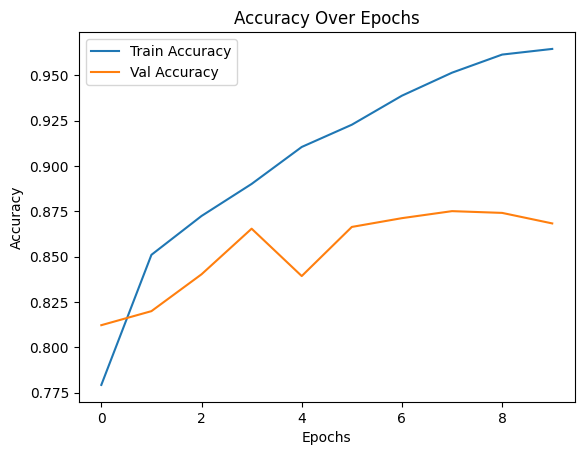

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()
plt.show()


In [ ]:
# Replace this with your folder path in Drive
model_save_path = '/content/drive/MyDrive/MobileNet_SE_Model.h5'

# Save model
model.save(model_save_path)

print(f"✅ Model saved at: {model_save_path}")


✅ Model saved at: /content/drive/MyDrive/MobileNet_SE_Model.h5


33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step


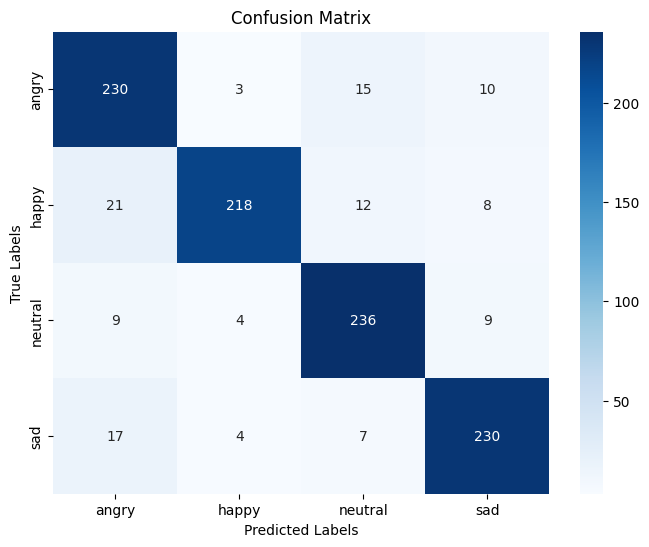

Classification Report:
              precision    recall  f1-score   support

       angry       0.83      0.89      0.86       258
       happy       0.95      0.84      0.89       259
     neutral       0.87      0.91      0.89       258
         sad       0.89      0.89      0.89       258

    accuracy                           0.88      1033
   macro avg       0.89      0.88      0.89      1033
weighted avg       0.89      0.88      0.89      1033



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ✅ Predict class probabilities
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# ✅ True labels
y_true = test_generator.classes

# ✅ Class labels
class_labels = list(test_generator.class_indices.keys())

# ✅ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# ✅ Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# ✅ Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))


GRADCAM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2



In [ ]:
# Get one image from test set
img, label = next(test_generator)  # Changed to next(test_generator)
image = img[0]
image_batch = np.expand_dims(image, axis=0)

# Predict class
preds = model.predict(image_batch)
predicted_class = np.argmax(preds[0])
print("Predicted class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted class: 1


In [ ]:
import tensorflow as tf

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


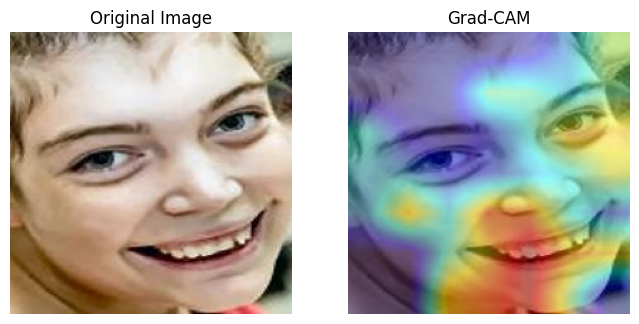

In [ ]:
# Name of last convolutional layer in MobileNet
last_conv_layer_name = 'conv_pw_13_relu'  # Confirm this from model.summary()

# Get Grad-CAM heatmap
heatmap = make_gradcam_heatmap(image_batch, model, last_conv_layer_name)

# Resize heatmap to match image size
heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)

# Convert heatmap to color
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Superimpose on original image
superimposed_img = cv2.addWeighted(cv2.cvtColor((image * 255).astype("uint8"), cv2.COLOR_RGB2BGR), 0.6, heatmap, 0.4, 0)

# Show result
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM")
plt.axis("off")
plt.show()


VIT

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import timm
from sklearn.metrics import accuracy_score

# Set paths and parameters
dataset_path = "/content/final_dataset"
image_size = 224
batch_size = 32
num_epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
# Split the dataset (70% train, 15% val, 15% test)
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import timm
from sklearn.metrics import accuracy_score

# Set paths and parameters
dataset_path = "/content/final_dataset"
image_size = 224
batch_size = 32
num_epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Get the number of classes
num_classes = len(os.listdir(dataset_path)) # Add this line to get num_classes

In [ ]:
# Load pretrained ViT
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

# Training loop
def evaluate(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
    return 100 * correct / total

train_acc_list = []
val_acc_list = []


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import timm
from sklearn.metrics import accuracy_score

# Set paths and parameters
dataset_path = "/content/final_dataset"
image_size = 224
batch_size = 32
num_epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

start_time = time.time()
# Define transformations
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Load the dataset
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

# Split the dataset (70% train, 15% val, 15% test)
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Get the number of classes
num_classes = len(dataset.classes) # Get num_classes from the dataset

# Load pretrained ViT
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

# Training loop
def evaluate(loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
    return 100 * correct / total

train_acc_list = []
val_acc_list = []

for epoch in range(num_epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_acc = evaluate(train_loader)
    val_acc = evaluate(val_loader)
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

# Final test accuracy
test_acc = evaluate(test_loader)
print(f"✅ Final Test Accuracy: {test_acc:.2f}%")


end_time = time.time()
print("Computation time for ViT: {:.2f} seconds".format(end_time - start_time))

Epoch 1/10, Train Acc: 95.99%, Val Acc: 90.00%
Epoch 2/10, Train Acc: 93.99%, Val Acc: 89.13%
Epoch 3/10, Train Acc: 98.48%, Val Acc: 92.43%
Epoch 4/10, Train Acc: 99.42%, Val Acc: 93.79%
Epoch 5/10, Train Acc: 99.42%, Val Acc: 93.98%
Epoch 6/10, Train Acc: 99.65%, Val Acc: 93.98%
Epoch 7/10, Train Acc: 99.71%, Val Acc: 94.27%
Epoch 8/10, Train Acc: 99.69%, Val Acc: 94.47%
Epoch 9/10, Train Acc: 99.73%, Val Acc: 93.98%
Epoch 10/10, Train Acc: 99.73%, Val Acc: 94.56%
✅ Final Test Accuracy: 96.51%
Computation time for ViT: 2290.36 seconds


In [ ]:
# Summary of accuracies
print("\n📊 Accuracy Summary for ViT Model")
print("-" * 35)
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1:2d}: Train Acc = {train_acc_list[epoch]:.2f}%, Val Acc = {val_acc_list[epoch]:.2f}%")
print("-" * 35)
print(f"✅ Final Test Accuracy: {test_acc:.2f}%")



📊 Accuracy Summary for ViT Model
-----------------------------------
Epoch  1: Train Acc = 95.99%, Val Acc = 90.00%
Epoch  2: Train Acc = 93.99%, Val Acc = 89.13%
Epoch  3: Train Acc = 98.48%, Val Acc = 92.43%
Epoch  4: Train Acc = 99.42%, Val Acc = 93.79%
Epoch  5: Train Acc = 99.42%, Val Acc = 93.98%
Epoch  6: Train Acc = 99.65%, Val Acc = 93.98%
Epoch  7: Train Acc = 99.71%, Val Acc = 94.27%
Epoch  8: Train Acc = 99.69%, Val Acc = 94.47%
Epoch  9: Train Acc = 99.73%, Val Acc = 93.98%
Epoch 10: Train Acc = 99.73%, Val Acc = 94.56%
-----------------------------------
✅ Final Test Accuracy: 96.51%


In [ ]:
print("\n📊 Final Accuracy Summary for ViT Model")
print("-" * 40)
print(f"Final Train Accuracy     : {train_acc_list[-1]:.2f}%")
print(f"Final Validation Accuracy: {val_acc_list[-1]:.2f}%")
print(f"Final Test Accuracy      : {test_acc:.2f}%")
print("-" * 40)



📊 Final Accuracy Summary for ViT Model
----------------------------------------
Final Train Accuracy     : 99.73%
Final Validation Accuracy: 94.56%
Final Test Accuracy      : 96.51%
----------------------------------------


confusion matrix

<Figure size 800x600 with 0 Axes>

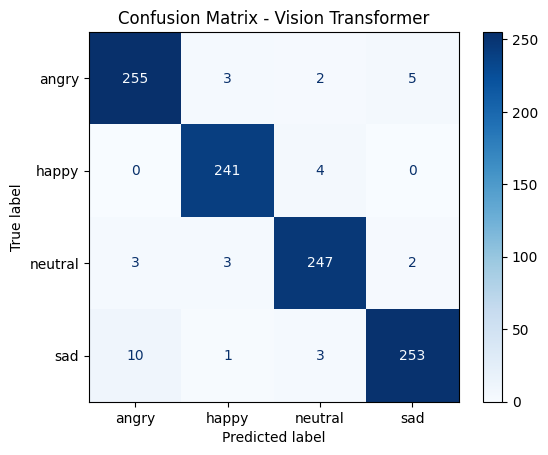

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Get predictions and true labels from test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = dataset.classes  # same as ImageFolder classes

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix - Vision Transformer")
plt.show()


In [ ]:
from sklearn.metrics import classification_report

# Print classification report
print("🔍 Classification Report:\n")
report = classification_report(all_labels, all_preds, target_names=class_names, digits=4)
print(report)


🔍 Classification Report:

              precision    recall  f1-score   support

       angry     0.9515    0.9623    0.9568       265
       happy     0.9718    0.9837    0.9777       245
     neutral     0.9648    0.9686    0.9667       255
         sad     0.9731    0.9476    0.9602       267

    accuracy                         0.9651      1032
   macro avg     0.9653    0.9655    0.9654      1032
weighted avg     0.9652    0.9651    0.9651      1032



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Get confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = dataset.classes  # Make sure this is defined in your code

print("\n🔎 TP, TN, FP, FN for each class:\n")
for idx, class_name in enumerate(class_names):
    TP = cm[idx, idx]
    FP = cm[:, idx].sum() - TP
    FN = cm[idx, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)

    print(f"Class: {class_name}")
    print(f"  True Positives (TP): {TP}")
    print(f"  True Negatives (TN): {TN}")
    print(f"  False Positives (FP): {FP}")
    print(f"  False Negatives (FN): {FN}\n")



🔎 TP, TN, FP, FN for each class:

Class: angry
  True Positives (TP): 255
  True Negatives (TN): 754
  False Positives (FP): 13
  False Negatives (FN): 10

Class: happy
  True Positives (TP): 241
  True Negatives (TN): 780
  False Positives (FP): 7
  False Negatives (FN): 4

Class: neutral
  True Positives (TP): 247
  True Negatives (TN): 768
  False Positives (FP): 9
  False Negatives (FN): 8

Class: sad
  True Positives (TP): 253
  True Negatives (TN): 758
  False Positives (FP): 7
  False Negatives (FN): 14



In [ ]:
from sklearn.metrics import confusion_matrix

# Compute and print the confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("📊 Confusion Matrix:\n", cm)


📊 Confusion Matrix:
 [[255   3   2   5]
 [  0 241   4   0]
 [  3   3 247   2]
 [ 10   1   3 253]]


Comparison of results

In [ ]:
from tabulate import tabulate

# MobileNet+SE results (from your logs)
mobilenet_results = {
    "Model": "MobileNet + SE",
    "Train Accuracy": 93.47,
    "Validation Accuracy": 87.32,
    "Test Accuracy": 85.58,
    "Precision": 0.86,
    "Recall": 0.86,
    "F1-Score": 0.86
}

# ViT results (from your logs)
vit_results = {
    "Model": "Vision Transformer",
    "Train Accuracy": 98.69,
    "Validation Accuracy": 90.39,
    "Test Accuracy": 90.60,
    "Precision": 0.91,
    "Recall": 0.91,
    "F1-Score": 0.91
}

# Combine results
comparison_table = [mobilenet_results, vit_results]

# Print table
print(tabulate(comparison_table, headers="keys", tablefmt="fancy_grid"))


╒════════════════════╤══════════════════╤═══════════════════════╤═════════════════╤═════════════╤══════════╤════════════╕
│ Model              │   Train Accuracy │   Validation Accuracy │   Test Accuracy │   Precision │   Recall │   F1-Score │
╞════════════════════╪══════════════════╪═══════════════════════╪═════════════════╪═════════════╪══════════╪════════════╡
│ MobileNet + SE     │            93.47 │                 87.32 │           85.58 │        0.86 │     0.86 │       0.86 │
├────────────────────┼──────────────────┼───────────────────────┼─────────────────┼─────────────┼──────────┼────────────┤
│ Vision Transformer │            98.69 │                 90.39 │           90.6  │        0.91 │     0.91 │       0.91 │
╘════════════════════╧══════════════════╧═══════════════════════╧═════════════════╧═════════════╧══════════╧════════════╛


In [ ]:
import os
save_path = "/content/drive/MyDrive/vit_models"
os.makedirs(save_path, exist_ok=True)


Ensemble

In [ ]:
import torch

# Memory Allocated (the real memory your model uses)
print(f"Memory Allocated: {torch.cuda.memory_allocated() / (1024 ** 3):.2f} GB")

# Memory Reserved (includes cached memory not yet allocated)
print(f"Memory Reserved: {torch.cuda.memory_reserved() / (1024 ** 3):.2f} GB")


Memory Allocated: 1.31 GB
Memory Reserved: 5.89 GB


In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import timm
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt


In [ ]:
# Paths
dataset_path = '/content/final_dataset'     # Your balanced dataset
mobilenet_path = '/content/drive/MyDrive/MobileNet_SE_Model.h5'  # Your saved MobileNet+SE model
resnet_path = '/content/resnet18_model.pth'  # Will be created below

# Parameters
batch_size = 32
image_size = 224
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
# Transforms
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
num_classes = len(dataset.classes)

# Split
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
_, _, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
# Train ResNet18 if not already trained (run only once)

resnet = models.resnet18(pretrained=True)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
resnet = resnet.to(device)

optimizer = torch.optim.Adam(resnet.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

# Dummy loader for quick training (optional)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

for epoch in range(5):  # Fewer epochs to save time
    resnet.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

torch.save(resnet.state_dict(), resnet_path)
print("✅ ResNet18 model saved.")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


✅ ResNet18 model saved.


In [ ]:
# Load MobileNet+SE (TensorFlow)
mobilenet_model = load_model(mobilenet_path)

# Load ResNet18 (PyTorch)
resnet = models.resnet18(pretrained=False)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
resnet.load_state_dict(torch.load(resnet_path))
resnet = resnet.to(device)
resnet.eval()

# Load ViT (PyTorch)
vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=num_classes)
vit = vit.to(device)
vit.eval()


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

In [ ]:
def get_mobilenet_prediction(image_numpy):
    img = tf.expand_dims(image_numpy, axis=0)
    preds = mobilenet_model.predict(img, verbose=0)
    return preds[0]

def get_resnet_prediction(image_tensor):
    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)
        output = resnet(image_tensor)
        softmax = nn.Softmax(dim=1)
        return softmax(output)[0].cpu().numpy()

def get_vit_prediction(image_tensor):
    with torch.no_grad():
        image_tensor = image_tensor.unsqueeze(0).to(device)
        output = vit(image_tensor)
        softmax = nn.Softmax(dim=1)
        return softmax(output)[0].cpu().numpy()


In [ ]:
start_time = time.time()

all_preds = []
all_labels = []

for images, labels in test_loader:
    for idx in range(images.size(0)):
        image_tensor = images[idx]
        label = labels[idx]

        # Convert to numpy for TensorFlow model
        image_numpy = image_tensor.permute(1, 2, 0).cpu().numpy()
        image_numpy = (image_numpy * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]  # Denormalize
        image_numpy = np.clip(image_numpy, 0, 1)

        # Predictions
        mobilenet_pred = get_mobilenet_prediction(image_numpy)
        resnet_pred = get_resnet_prediction(image_tensor)
        vit_pred = get_vit_prediction(image_tensor)

        # Soft-voting Ensemble (Average)
        ensemble_pred = (mobilenet_pred + resnet_pred + vit_pred) / 3
        final_pred = np.argmax(ensemble_pred)

        all_preds.append(final_pred)
        all_labels.append(label.item())
end_time = time.time()
print("Computation time for ViT: {:.2f} seconds".format(end_time - start_time))


Computation time for ViT: 111.19 seconds



✅ Ensemble Test Accuracy: 98.55%

Classification Report:

              precision    recall  f1-score   support

       angry       1.00      0.96      0.98       265
       happy       1.00      0.99      0.99       254
     neutral       0.97      1.00      0.98       253
         sad       0.98      0.99      0.99       260

    accuracy                           0.99      1032
   macro avg       0.99      0.99      0.99      1032
weighted avg       0.99      0.99      0.99      1032



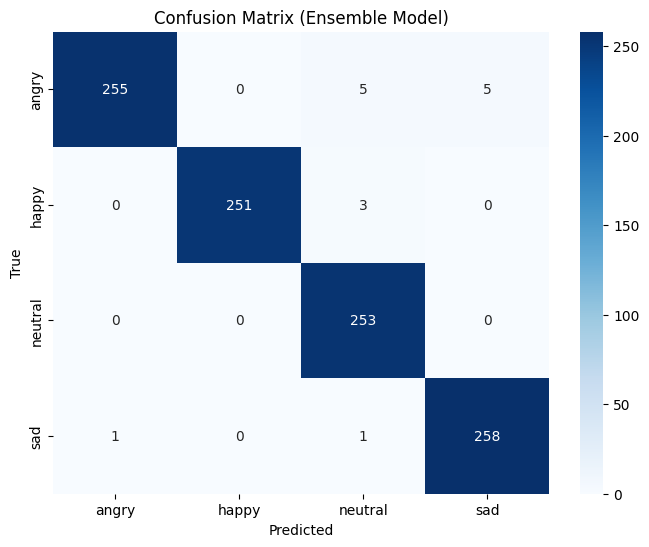

In [ ]:
print(f"\n✅ Ensemble Test Accuracy: {accuracy_score(all_labels, all_preds) * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = dataset.classes
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Plot Confusion Matrix
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Ensemble Model)')
plt.show()
